In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS

assay_type = pl.read_parquet("../../data/iedb_meta/assay_type.parquet")
receptor_reference = pl.read_parquet("../../data/iedb_meta/receptor_reference.parquet")


iedb_II_conf = pl.read_parquet(
    "../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet"
).with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae"))
iedb_II = iedb_II_conf.explode("references")

cresta = pl.read_parquet(
    "../../data/cresta/triad/cresta_triad.conf_af3.parquet"
).with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae"))

iedb_I_conf = pl.read_parquet(
    "../../data/iedb_I/triad/iedb_I_triad.conf_af3.parquet"
).with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae"))
iedb_I = iedb_I_conf.explode("references")

In [3]:
iedb_II.filter(pl.col("cognate"))

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,receptor_id,references,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,…,mean_p_tcr_interface_contact_prob,mean_tcr_p_interface_contact_prob,mean_tcr_pmhc_interface_contact_prob,mean_pmhc_tcr_interface_contact_prob,mean_p_tcr_pae,mean_tcr_p_pae,mean_mhc_tcr_pae,mean_tcr_mhc_pae,mean_p_tcr_contact_prob,mean_tcr_p_contact_prob,mean_mhc_tcr_contact_prob,mean_tcr_mhc_contact_prob,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae,peptide_mean_pLDDT_II
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],str,bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""0007d377934b075588b311883f901e…",true,"""AMERNAGSGIIISDT""","""II""","""alpha""","""human""","""DQA1*01:02""","""EDIVADHVASCGVNLYQFYGPSGQYTHEFD…","""beta""","""human""","""DQB1*06:02""","""RDSPEDFVFQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""SQQGEEDPQALSIQEGENATMNCSYKTSIN…","""beta""","""human""","""DGGITQSPKYLFRKEGQNVTLSCEQNLNHD…","""TSINN""","""IRSNERE""","""DTSKKS""","""CATGHTGANSKLTF""","""LNHDA""","""SQIVND""","""EKKES""","""CASSLQGTPNGNQPQHF""","[""213484""]","""1041206""",false,"[0.76, 0.84, … 0.8]","[[0.02, 0.84, … 0.69], [0.84, 0.88, … 0.83], … [0.69, 0.83, … 0.88]]","[[0.76, 1.43, … 2.39], [1.53, 0.76, … 1.36], … [1.93, 1.58, … 0.76]]","[0.02, 0.88, … 0.88]",0.08,0.0,0.89,0.9,…,0.04772,0.04772,0.013885,0.013885,-9.493818,6.521439,7.736978,8.93506,0.00657,0.00657,0.000657,0.000657,11,20,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 1.0], … [0.0, 0.0, … 0.0]]",77.887641,84.197568,87.175968,90.663778,81.265258,91.57718,88.704565,91.264762,84.013548,86.149471,89.69879,10.497334,6.62677,3.152518,7.129286,0.059749,0.059749,2.39,1.36,1.93,1.58,83.794592
"""002ffa37018430f0151bbdb46f50e6…",true,"""IHSLLDEGKQSLTKL""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*15:03""","""GDTRPRFLWQPKRECHFFNGTERVRFLDRH…","""alpha""","""human""","""QKEVEQDPGPLSVPEGAIVSLNCTYSNSAF…","""beta""","""human""","""SAVISQKPSRDICQRGTSLTIQCQVDSQVT…","""NSAFQY""","""TYSSGN""","""DKSSKY""","""CAMSARSGNTPLVF""","""SQVTM""","""ANQGSEA""","""PNLTF""","""CSLRDAKETQYF""","[""521""]","""1025316""",false,"[0.3, 0.53, … 0.46]","[[0.01, 0.39, … 0.2], [0.39, 0.87, … 0.43], … [0.2, 0.43, … 0.86]]","[[0.76, 9.03, … 14.27], [7.03, 0.76, … 8.73], … [10.74, 7.93, … 0.76]]","[0.01, 0.87, … 0.86]",0.06,0.0,0.67,0.75,…,0.046529,0.046529,0.010353,0.010353,-25.291302,15.35816,15.997989,17.405933,0.006121,0.006121,0.000505,0.000505,0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]",33.971864,73.962157,64.320931,84.6044,75.350303,72.944324,79.47,85.848048,74.209901,76.062607,81.5806,24.312263,12.219131,10.370275,18.775427,0.055882,0.055882,11.41,7.2,10.31,7.06,36.014851
"""005700f760ca7a6a9d0585b73ef307…",true,"""GDPDMMRYVDKYGQL""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*15:01""","""GDTRPRFLWQPKRECHFFNGTERVRFLDRY…","""alpha""",

In [2]:
iedb_I.filter(pl.col("cognate"))

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,receptor_id,references,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,…,mean_pmhc_tcr_interface_pae,mean_p_tcr_interface_contact_prob,mean_tcr_p_interface_contact_prob,mean_tcr_pmhc_interface_contact_prob,mean_pmhc_tcr_interface_contact_prob,mean_p_tcr_pae,mean_tcr_p_pae,mean_mhc_tcr_pae,mean_tcr_mhc_pae,mean_p_tcr_contact_prob,mean_tcr_p_contact_prob,mean_mhc_tcr_contact_prob,mean_tcr_mhc_contact_prob,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],str,bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""0002490f83f0aea07fb5e30580d87b…",true,"""TTDPSFLGRY""","""I""","""heavy""","""human""","""A*01:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""AQSVAQPEDQVNVAEGNPLTVKCTYSVSGN…","""beta""","""human""","""DAMVIQNPRYQVTQFGKPVTLSCSQTLNHN…","""VSGNPY""","""YITGDNLV""","""NKSQTS""","""CAVRALIGFGNVLHCFGNVLHC""","""LNHNV""","""YYDKDF""","""PNTSF""","""CATSGDYGGSISDTQYF""","[""203260""]","""1039300""",false,"[0.43, 0.5, … 0.27]","[[0.02, 0.87, … 0.05], [0.87, 0.88, … 0.12], … [0.05, 0.12, … 0.85]]","[[0.76, 1.26, … 26.360001], [1.04, 0.76, … 25.129999], … [22.209999, 17.559999, … 0.76]]","[0.02, 0.88, … 0.85]",0.07,0.0,0.57,0.62,…,26.120407,31.0,31.0,0.003107,0.003107,-27.829327,26.246386,28.18037,26.58457,0.001534,0.001534,0.00071,0.00071,0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]",75.347683,65.138409,77.234033,86.294889,49.905,75.351708,65.290667,83.964103,67.404472,66.310226,87.178664,10.541827,5.369581,2.711114,6.667038,0.061633,0.061633,22.6,20.889999,21.450001,17.559999
"""0009491224ca3e0ab91521d2d28be4…",true,"""GILGFVFTL""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""GENVEQHPSTLSVQEGDSAVIKCTYSDSAS…","""beta""","""human""","""DGGITQSPKYLFRKEGQNVTLSCEQNLNHD…","""DSASNY""","""IRSNVGE""","""NKTAKH""","""CAVQGSQGNLIF""","""LNHDA""","""SQIVND""","""EKKES""","""CASSIRAAETQYF""","[""1986""]","""1031507""",false,"[0.83, 0.88, … 0.83]","[[0.03, 0.96, … 0.85], [0.96, 0.89, … 0.87], … [0.85, 0.87, … 0.88]]","[[0.76, 1.14, … 1.41], [1.01, 0.76, … 1.12], … [1.33, 1.29, … 0.76]]","[0.03, 0.89, … 0.88]",0.07,0.0,0.88,0.89,…,2.897788,0.080171,0.080171,0.012793,0.012793,-3.544315,4.987339,7.246988,8.103312,0.009367,0.009367,0.000534,0.000534,14,20,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]",94.20942,84.660445,80.181509,88.079583,83.307882,95.524872,94.664565,92.483333,94.2074,88.981244,93.575945,4.268838,4.611842,1.690631,2.304074,0.055144,0.055144,1.41,1.12,1.33,1.29
"""000f08ca0bcb431fc2fa81a77e895b…",true,"""LLWNGPMAV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha"""

In [3]:
import matplotlib.pyplot as plt
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc
import sklearn.metrics as metrics
from scipy.stats import mannwhitneyu, norm, false_discovery_control
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import OrderedDict, defaultdict
from matplotlib import transforms


def plot_violins(
    label,
    values,
    pos_triads,
    title=None,
    jitter=0.08,
    point_size=18,
    point_alpha=0.6,
    label_y=1.02,
):
    n = len(label)
    fig, ax = plt.subplots(figsize=(max(6, 0.8 * n), 4))

    # Violin plot
    vp = ax.violinplot(
        values,
        positions=range(1, n + 1),
        widths=0.8,
        showmedians=True,
        showextrema=False,
    )
    for body in vp["bodies"]:
        body.set_alpha(0.7)

    # Overlay points with jitter
    rng = np.random.default_rng()
    for i, vl_list in enumerate(values):
        v = np.asarray(vl_list, dtype=float)
        v = v[np.isfinite(v)]
        if v.size == 0:
            continue

        x = np.full(v.shape, i + 1, dtype=float) + rng.uniform(
            -jitter, jitter, size=v.size
        )
        ax.scatter(
            x,
            v,
            s=point_size,
            alpha=point_alpha,
            linewidths=0.5,
            edgecolors="black",
            facecolors="white",
            zorder=3,
        )

    # Place "n=" labels above the axes (between top spine and title)
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    for i, vl_list in enumerate(values):
        ax.text(
            i + 1,
            label_y,
            f"pMHC:studies={len(vl_list)}\npos triads={pos_triads[i]}",
            transform=trans,
            ha="center",
            va="bottom",
            rotation=45,
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.3),
            clip_on=False,
        )

    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels(label, rotation=45, ha="right")
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylabel("AUC")
    if title is not None:
        ax.set_title(title)
    return fig, ax


def auc_assay_type(
    df,
    featnames,
    mhc_class,
):
    grouping_cols = FORMAT_ANTIGEN_COLS + ["references"]
    antigen_st = df.filter(pl.col("cognate")).select(grouping_cols).unique()

    feat_df = []

    for row in antigen_st.iter_rows(named=True):

        focal_a_st = pl.DataFrame([row]).select(pl.exclude("job_name"))

        ref = row["references"]
        if mhc_class == "I":
            hla = row["mhc_1_name"]
            antigen = row["mhc_1_name"] + "::" + row["peptide"]
        else:
            hla = row["mhc_2_name"]
            antigen = row["mhc_2_name"] + "::" + row["peptide"]

        focal_pos = df.join(focal_a_st, on=grouping_cols)

        focal_pos = focal_pos.explode("receptor_id").join(
            receptor_reference,
            left_on=["references", "receptor_id"],
            right_on=["reference_id", "receptor_id"],
        )

        focal_neg = df.join(
            focal_pos.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ).filter(~pl.col("cognate"))

        focal_pos_by_at = focal_pos.partition_by("assay_type")

        for at_partition in focal_pos_by_at:
            at = at_partition.select("assay_type")[0].item()
            focal_triad = pl.concat(
                [
                    at_partition.select(pl.exclude("assay_type", "receptor_id")),
                    focal_neg.select(pl.exclude("receptor_id")),
                ]
            )

            for feat in featnames:
                dat = focal_triad.select(feat, "cognate").to_numpy()

                fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
                # roc_auc = abs(metrics.auc(fpr, tpr) - 0.5) + 0.5
                roc_auc = metrics.auc(fpr, tpr)

                feat_df.append(
                    {
                        "auc": roc_auc,
                        # "fpr": list(fpr),
                        # "tpr": list(tpr),
                        "featname": feat,
                        "assay_type": at,
                        "antigen": antigen,
                        "n_pos": focal_triad.filter(pl.col("cognate")).height,
                    }
                )

    feat_df = pl.DataFrame(feat_df)

    return feat_df


feats = [
    "iptm",
    "mean_p_tcr_pae",
]

## By antigen:study


In [4]:
auc_at_II = auc_assay_type(iedb_II, feats, "II")
auc_at_I = auc_assay_type(iedb_I, feats, "I")

(<Figure size 1440x400 with 1 Axes>, <Axes: ylabel='AUC'>)

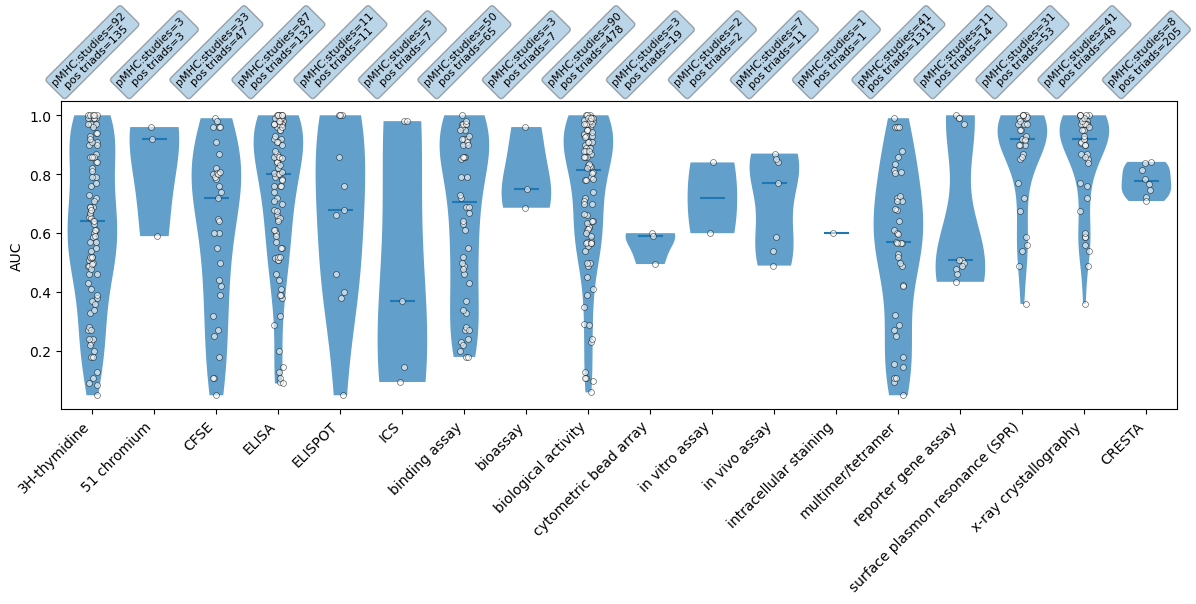

In [5]:
from tcrtrifold.eval_utils import antigen_raw_score_auc

featname = "mean_p_tcr_pae"

auc_at_cresta = antigen_raw_score_auc(
    cresta,
    featname,
)

auc_at_cresta = auc_at_cresta.join(
    cresta.filter(pl.col("cognate"))
    .group_by(FORMAT_ANTIGEN_COLS)
    .agg(pl.len().alias("n_pos")),
    on=FORMAT_ANTIGEN_COLS,
)

cresta_auc = [auc_at_cresta.select("roc_auc").to_series().to_list()]
cresta_npos = [auc_at_cresta.select("n_pos").sum().item()]
cresta_labels = ["CRESTA"]


auc_partition_II_antigen = (
    auc_at_II.filter(pl.col("featname") == featname)
    .group_by(pl.col("assay_type"))
    .agg(pl.col("auc"), pl.len().alias("n_as"), pl.col("n_pos").sum().alias("n_pos"))
).sort(by="assay_type", descending=False)


plot_violins(
    auc_partition_II_antigen.select("assay_type").to_series().to_list() + cresta_labels,
    auc_partition_II_antigen.select("auc").to_series().to_list() + cresta_auc,
    auc_partition_II_antigen.select("n_pos").to_series().to_list() + cresta_npos,
    # title="AUC violins per assay-type per antigen-study (IEDB II)",
)

(<Figure size 1280x400 with 1 Axes>, <Axes: ylabel='AUC'>)

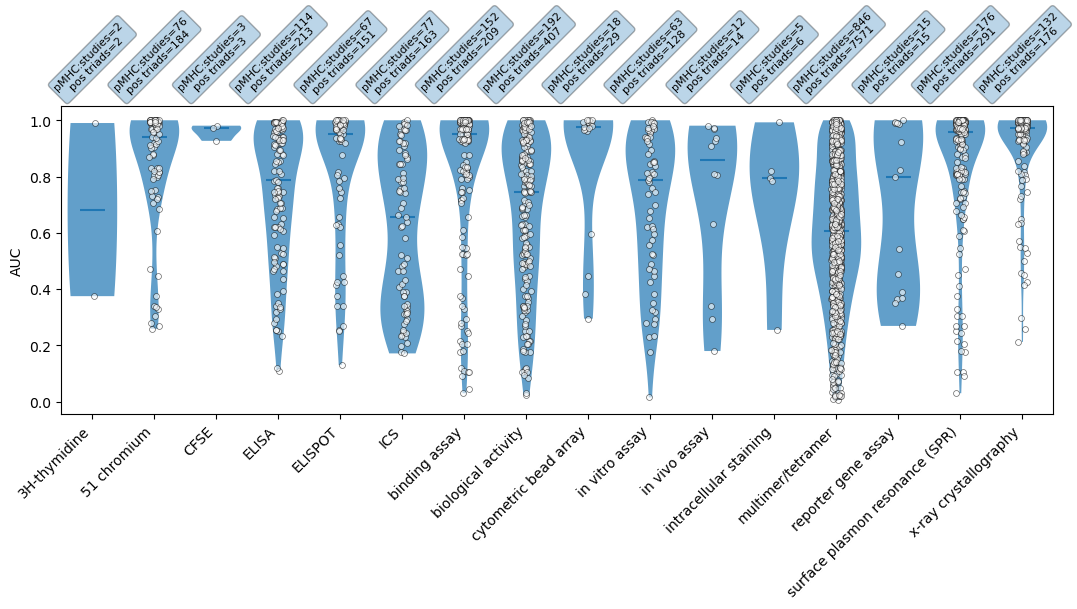

In [6]:
featname = "iptm"


auc_partition_I_antigen = (
    auc_at_I.filter(pl.col("featname") == featname)
    .group_by(pl.col("assay_type"))
    .agg(pl.col("auc"), pl.len().alias("n_as"), pl.col("n_pos").sum().alias("n_pos"))
).sort(by="assay_type", descending=False)


plot_violins(
    auc_partition_I_antigen.select("assay_type").to_series().to_list(),
    auc_partition_I_antigen.select("auc").to_series().to_list(),
    auc_partition_I_antigen.select("n_pos").to_series().to_list(),
    #     title="AUC violins per assay-type per antigen-study (IEDB I)",
)

<Axes: title={'center': 'CRESTA, mean-p:TCR PAE AUC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

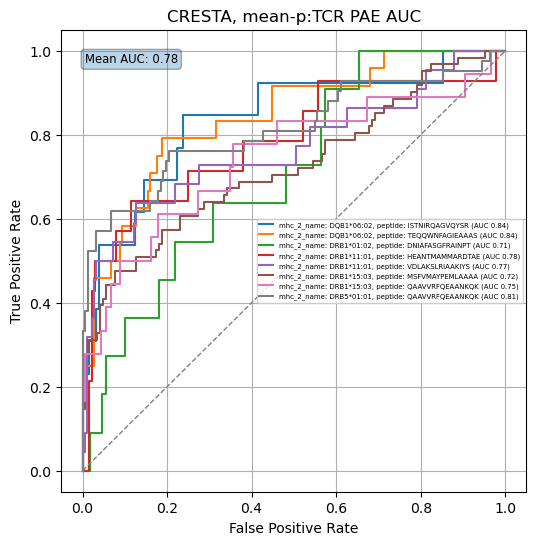

In [7]:
from tcrtrifold.viz_utils import plot_auc_per_antigen

plot_auc_per_antigen(
    auc_at_cresta, title="CRESTA, mean-p:TCR PAE AUC", id_cols=["mhc_2_name", "peptide"]
)

In [8]:
from mdaf3.AF3OutputParser import AF3Output
from pathlib import Path

jn = cresta.select("job_name")[0].item()
af3_out = AF3Output(Path(f"../../data/cresta/triad/inference/{jn}"))
u = af3_out.get_mda_universe()

print(cresta.select("peptide")[0].item())
print(cresta.select("mhc_1_seq")[0].item())
print(cresta.select("mhc_2_seq")[0].item())
print(cresta.select("tcr_1_seq")[0].item())
print(cresta.select("tcr_2_seq")[0].item())

QAAVVRFQEAANKQK
KEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTPITNVPPEVTVLTNSPVELREPNVLICFIDKFTPPVVNVTWLRNGKPVTTGVSETVFLPREDHLFRKFHYLPFLPSTEDVYDCRVEHWGLDEPLLKHWEFDAPSPLPETTE
GDTRPRFLWQPKRECHFFNGTERVRFLDRHFYNQEESVRFDSDVGEFRAVTELGRPDAEYWNSQKDILEQARAAVDTYCRHNYGVVESFTVQRRVQPKVTVYPSKTQPLQHHNLLVCSVSGFYPGSIEVRWFLNGQEEKAGMVSTGLIQNGDWTFQTLVMLETVPRSGEVYTCQVEHPSVTSPLTVEWRARSESAQSK
AQSVTQLGSHVSVSEGALVLLRCNYSSSVPPYLFWYVQYPNQGLQLLLKYTTGATLVKGINGFEAEFKKSETSFHLTKPSAHMSDAAEYFCAVSESKAAGNKLTFGGGTRVLVKPIQNPDPAVYQLRDSKSSDKSVCLFTDFDSQTNVSQSKDSDVYITDKTVLDMRSMDFKSNSAVAWSNKSDFACANAFNNSIIPEDTFFPSPESSCDVKLVEKSFETDTNLNFQNLSVIGFRILLLKVAGFNLLMTLRLWSS
DTGVSQDPRHKITKRGQNVTFRCDPISEHNRLYWYRQTLGQGPEFLTYFQNEAQLEKSRLLSDRFSAERPKGSFSTLEIQRTEQGDSAMYLCASSPSGGTGASEQYFGPGTRLTVTDLNKVFPPEVAVFEPSEAEISHTQKATLVCLATGFFPDHVELSWWVNGKEVHSGVSTDPQPLKEQPALNDSRYCLSSRLRVSATFWQNPRNHFRCQVQFYGLSENDEWTQDRAKPVTQIVSAEAWGRADCGFTSVSYQQGVLSATILYEILLGKATLYAVLVSALVLMAMVKRKDF


/home/lwoods/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/MDAnalysis/coordinates/MMCIF.py:139: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


In [ ]:
iedb_I
